# Ultimate NIDS Pipeline: Supervised Vector Space Engineering
**Goal:** Fix the "Zero Recall" on R2L/U2R by warping the feature space to maximize class separation.

**The "Unconventional" Approach: LDA + Centroid Heatmaps**
Standard scaling isn't enough because R2L overlaps with Normal. We perform explicit operations on the vector space to pull them apart.

**New Architecture:**
1.  **Manifold Mixup:** We use Linear Interpolation to generate high-quality synthetic R2L/U2R samples that preserve the attack's geometric structure.
2.  **LDA Projection:** We project the data onto axes that mathematically maximize the separation between classes.
3.  **Centroid Distance Features:** We calculate the distance of every sample to the "Center" of the R2L and U2R clusters, adding these as explicit risk features.
4.  **Deep MLP + Risk-Sensitive Inference:** The final classifier uses this enriched vector space.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# The New Stack: LDA & Metric Learning
from sklearn.neural_network import MLPClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, pairwise_distances

# Config
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

## 1. Data Loading

In [2]:
DATA_DIR = 'Data'
CSV_FILE = os.path.join(DATA_DIR, 'network_connections.csv')
MAP_FILE = os.path.join(DATA_DIR, 'attack2category_map.txt')

# 1. Load Mapping
attack_map = {'normal': 'normal'}
try:
    with open(MAP_FILE, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 2:
                attack_map[parts[0]] = parts[1]
except FileNotFoundError:
    print("Warning: Map file not found. Creating dummy map.")

# 2. Load Data
df = pd.read_csv(CSV_FILE)
df['label'] = df['label'].astype(str).str.replace('.', '', regex=False)
df['category'] = df['label'].map(attack_map).fillna('other')
df.drop_duplicates(inplace=True)
print(f"Data Loaded. Shape: {df.shape}")

Data Loaded. Shape: (125973, 43)


## 2. Vector Space Preparation

In [3]:
def prepare_vector_input(data, fit=False, encoders=None):
    df_vec = data.copy()
    
    # 1. Log Transform
    for col in ['src_bytes', 'dst_bytes', 'duration']:
        if col in df_vec.columns:
            df_vec[col] = np.log1p(df_vec[col])

    # 2. Categorical Handling: Frequency Encoding 
    cat_cols = ['protocol_type', 'service', 'flag']
    new_encoders = {}
    
    for col in cat_cols:
        if fit:
            freq_map = df_vec[col].value_counts(normalize=True).to_dict()
            df_vec[col] = df_vec[col].map(freq_map)
            new_encoders[col] = freq_map
        else:
            df_vec[col] = df_vec[col].map(encoders[col]).fillna(0)
            
    return df_vec, new_encoders

# Apply Preparation
X = df.drop(['label', 'category'], axis=1)
y = df['category']

X_vec, encoders = prepare_vector_input(X, fit=True)
y_vec = LabelEncoder().fit_transform(y)

# Split
X_train, X_test, y_train, y_test = train_test_split(X_vec, y_vec, test_size=0.2, stratify=y_vec, random_state=42)

print("Data vectorized.")

Data vectorized.


## 3. Manifold Mixup (Advanced Oversampling)
Instead of adding noise, we draw lines between existing points and sample from those lines. This creates cleaner synthetic data.

In [4]:
print("--- Performing Manifold Mixup Oversampling ---")

train_df = X_train.copy()
train_df['target'] = y_train

dfs = []
for cls in train_df['target'].unique():
    cls_df = train_df[train_df['target'] == cls]
    count = len(cls_df)
    
    # Aggressive Target for Rare Classes
    TARGET_COUNT = 4000
    
    if count < TARGET_COUNT:
        # Calculate how many synthetic samples needed
        needed = TARGET_COUNT - count
        
        # Mixup: Select random pairs of points from the class
        # x_new = alpha * x1 + (1-alpha) * x2
        indices = np.random.choice(cls_df.index, needed, replace=True)
        indices2 = np.random.choice(cls_df.index, needed, replace=True)
        
        part1 = cls_df.loc[indices].drop('target', axis=1).reset_index(drop=True)
        part2 = cls_df.loc[indices2].drop('target', axis=1).reset_index(drop=True)
        
        # Random alpha between 0 and 1
        alpha = np.random.uniform(0, 1, size=(needed, 1))
        synthetic = part1 * alpha + part2 * (1 - alpha)
        synthetic['target'] = cls
        
        print(f" > Manifold Mixup Class {cls}: {count} original + {needed} synthetic")
        dfs.append(cls_df)
        dfs.append(synthetic)
    else:
        # Cap max samples to prevent Normal from dominating
        dfs.append(cls_df.sample(n=min(count, 10000), random_state=42))

train_balanced = pd.concat(dfs).sample(frac=1, random_state=42)
X_train_bal = train_balanced.drop('target', axis=1)
y_train_bal = train_balanced['target']
print(f"Balanced Training Shape: {X_train_bal.shape}")

--- Performing Manifold Mixup Oversampling ---
 > Manifold Mixup Class 3: 796 original + 3204 synthetic
 > Manifold Mixup Class 4: 42 original + 3958 synthetic
Balanced Training Shape: (37325, 41)


## 4. Vector Space Engineering (LDA + Centroids)
We use LDA to find the optimal separation axes and add "Distance to Centroid" features.

In [5]:
print("--- Engineering Vector Space ---")

# 1. Standard Scaler (Base)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_bal)
X_test_sc = scaler.transform(X_test)

# 2. LDA Projection (Supervised Dimension Reduction)
# Projects data into (Classes - 1) dimensions optimized for separation
lda = LinearDiscriminantAnalysis()
X_train_lda = lda.fit_transform(X_train_sc, y_train_bal)
X_test_lda = lda.transform(X_test_sc)

print(f"LDA Projections Created. Dimensions: {X_train_lda.shape[1]}")

# 3. Centroid Distance Features (The Heatmap)
# Calculate the center of each class in the LDA space
centroids = []
classes = np.sort(train_balanced['target'].unique())

for cls in classes:
    # Get average vector for this class in LDA space
    center = X_train_lda[y_train_bal == cls].mean(axis=0)
    centroids.append(center)

centroids = np.array(centroids)

# Calculate Euclidean distance from every point to every class centroid
# This adds explicitly: "How far am I from the R2L center?"
X_train_dist = pairwise_distances(X_train_lda, centroids)
X_test_dist = pairwise_distances(X_test_lda, centroids)

# 4. Combine: Scaled Raw Features + LDA Coords + Distances
X_train_final = np.hstack([X_train_sc, X_train_lda, X_train_dist])
X_test_final = np.hstack([X_test_sc, X_test_lda, X_test_dist])

print(f"Final Vector Space Dimensions: {X_train_final.shape[1]} (Rich with Geometric Info)")

--- Engineering Vector Space ---
LDA Projections Created. Dimensions: 4
Final Vector Space Dimensions: 50 (Rich with Geometric Info)


## 5. Training Deep MLP

In [6]:
print("--- Training Deep Neural Network ---")

clf_mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    alpha=0.0001,
    batch_size=64,
    learning_rate='adaptive',
    max_iter=300,
    random_state=42,
    early_stopping=True
)

clf_mlp.fit(X_train_final, y_train_bal)
print("Neural Network Trained.")

--- Training Deep Neural Network ---
Neural Network Trained.


--- Loading NSL-KDD for Validation ---

>>> ENGINEERED VECTOR SPACE ACCURACY (NSL-KDD): 80.75%

Classification Report:
              precision    recall  f1-score   support

         dos       0.95      0.75      0.84      7636
      normal       0.76      0.96      0.85      9711
       probe       0.70      0.87      0.77      2423
         r2l       0.84      0.39      0.54      2574
         u2r       0.43      0.16      0.23       200

    accuracy                           0.81     22544
   macro avg       0.74      0.63      0.65     22544
weighted avg       0.83      0.81      0.80     22544



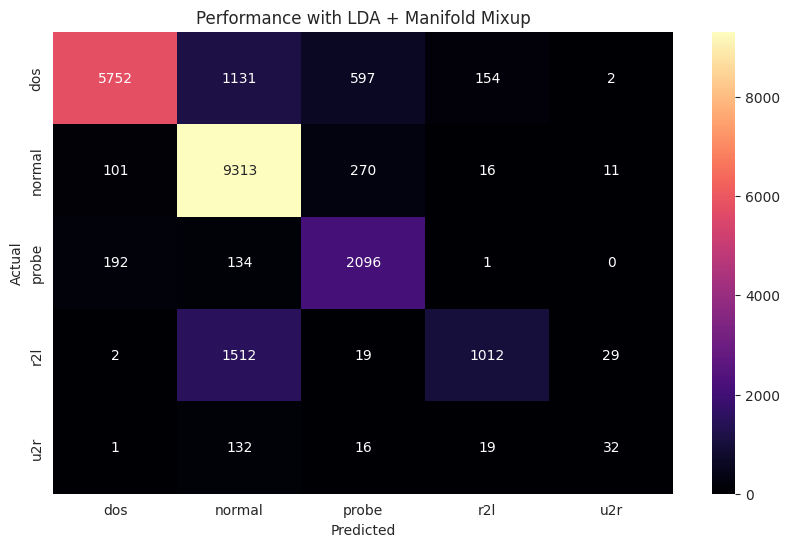

In [7]:
def predict_risk_sensitive(model, X, encoder, risk_factors):
    probs = model.predict_proba(X)
    classes = encoder.classes_
    
    for cls, factor in risk_factors.items():
        if cls in classes:
            idx = np.where(classes == cls)[0][0]
            probs[:, idx] *= factor
            
    pred_indices = np.argmax(probs, axis=1)
    return encoder.inverse_transform(pred_indices)

RISK_FACTORS = {
    'r2l': 3.0,  # Boost R2L (Lowered slightly as LDA should help separation naturally)
    'u2r': 3.0,  
    'probe': 1.2
}

le_final = LabelEncoder()
le_final.fit(y)

# --- NSL-KDD Validation ---
print("--- Loading NSL-KDD for Validation ---")
NSL_URL = "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTest%2B.txt"
NSL_COLS = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins',
    'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root',
    'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds',
    'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate',
    'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
    'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
    'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate',
    'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
    'dst_host_srv_rerror_rate', 'label', 'difficulty_level'
]

try:
    # Load
    df_nsl = pd.read_csv(NSL_URL, header=None, names=NSL_COLS)
    df_nsl.drop('difficulty_level', axis=1, inplace=True)
    df_nsl['label'] = df_nsl['label'].astype(str).str.replace('.', '', regex=False)
    df_nsl['category'] = df_nsl['label'].map(attack_map).fillna('other')
    
    X_nsl = df_nsl.drop(['label', 'category'], axis=1)
    y_nsl = df_nsl['category']
    
    # 1. Vectorize (Same Encoders)
    X_nsl_vec, _ = prepare_vector_input(X_nsl, fit=False, encoders=encoders)
    
    # 2. Transform Pipeline
    # A. Scale
    X_nsl_sc = scaler.transform(X_nsl_vec)
    # B. LDA Project
    X_nsl_lda = lda.transform(X_nsl_sc)
    # C. Distances
    X_nsl_dist = pairwise_distances(X_nsl_lda, centroids)
    # D. Stack
    X_nsl_final = np.hstack([X_nsl_sc, X_nsl_lda, X_nsl_dist])
    
    # 3. Predict
    y_nsl_pred = predict_risk_sensitive(clf_mlp, X_nsl_final, le_final, RISK_FACTORS)
    
    # Evaluate
    acc = accuracy_score(y_nsl, y_nsl_pred)
    print(f"\n>>> ENGINEERED VECTOR SPACE ACCURACY (NSL-KDD): {acc:.2%}")
    print("\nClassification Report:")
    print(classification_report(y_nsl, y_nsl_pred))
    
    labels = sorted(y_nsl.unique())
    cm = confusion_matrix(y_nsl, y_nsl_pred, labels=labels)
    plt.figure(figsize=(10, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='magma', xticklabels=labels, yticklabels=labels)
    plt.title("Performance with LDA + Manifold Mixup")
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

except Exception as e:
    print(f"Error: {e}")